# Analisis Exploratorio de Datos (AED)
## Proyecto Final - Data Science YPF

**Dataset:** [Give Me Some Credit](https://www.kaggle.com/c/GiveMeSomeCredit) (competencia de Kaggle).

**Objetivo del proyecto:** predecir la probabilidad de que una persona experimente dificultades financieras graves en los proximos dos anos (variable `SeriousDlqin2yrs`), a partir de datos historicos de comportamiento crediticio. Este es un problema de scoring de riesgo crediticio: en base al resultado, una entidad financiera podria decidir si otorgar o no una linea de credito.

En este notebook se realiza el AED: se explora la estructura del dataset, se identifican valores faltantes y outliers, se estudia la variable objetivo y se aplica una limpieza basica (feature engineering) que sirve de insumo para los notebooks de modelado.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

## 1. Carga de datos

In [2]:
df = pd.read_csv("../dataset/cs-training.csv", index_col=0)
print(df.shape)
df.head()

(150000, 11)


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 1 to 150000
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      150000 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 2   age                                   150000 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 4   DebtRatio                             150000 non-null  float64
 5   MonthlyIncome                         120269 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 7   NumberOfTimes90DaysLate               150000 non-null  int64  
 8   NumberRealEstateLoansOrLines          150000 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 10  NumberOfDependents                    146076 non-null  float64
dtypes: float64(

In [4]:
df.describe()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,1.202690e+05,150000.000000,150000.000000,150000.000000,150000.000000,146076.000000
mean,0.066840,6.048438,52.295207,0.421033,353.005076,6.670221e+03,8.452760,0.265973,1.018240,0.240387,0.757222
std,0.249746,249.755371,14.771866,4.192781,2037.818523,1.438467e+04,5.145951,4.169304,1.129771,4.155179,1.115086
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.029867,41.000000,0.000000,0.175074,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.154181,52.000000,0.000000,0.366508,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,0.000000,0.559046,63.000000,0.000000,0.868254,8.249000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,1.000000,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


## 2. Valores faltantes

`MonthlyIncome` y `NumberOfDependents` son las unicas columnas con valores nulos.

In [5]:
faltantes = df.isnull().sum()
faltantes_pct = (faltantes / len(df) * 100).round(2)
pd.DataFrame({"faltantes": faltantes, "% del total": faltantes_pct}).query("faltantes > 0")

,faltantes,% del total
MonthlyIncome,29731,19.82
NumberOfDependents,3924,2.62


## 3. Variable objetivo: `SeriousDlqin2yrs`

1 = la persona tuvo un atraso serio de pago (mora >= 90 dias) en los siguientes 2 anos. 0 = no lo tuvo.

SeriousDlqin2yrs
0    139974
1     10026
Name: count, dtype: int64
SeriousDlqin2yrs
0    93.32
1     6.68
Name: proportion, dtype: float64


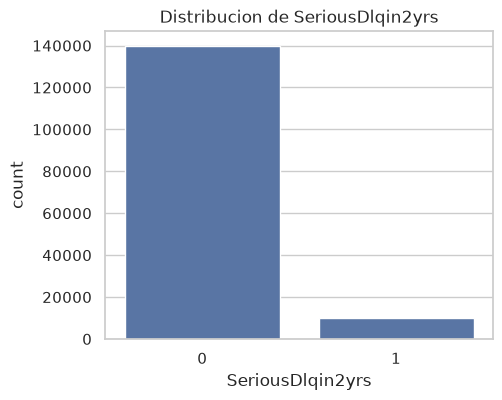

In [6]:
conteo = df["SeriousDlqin2yrs"].value_counts()
porcentaje = df["SeriousDlqin2yrs"].value_counts(normalize=True) * 100
print(conteo)
print(porcentaje.round(2))

fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(x="SeriousDlqin2yrs", data=df, ax=ax)
ax.set_title("Distribucion de SeriousDlqin2yrs")
plt.show()

**Hallazgo:** el dataset esta fuertemente desbalanceado — solo ~6-7% de los clientes tuvieron un incumplimiento serio. Esto va a condicionar como evaluamos los modelos supervisados (la accuracy sola no alcanza; hay que mirar precision, recall, f1 y AUC).

## 4. Distribucion de las variables numericas

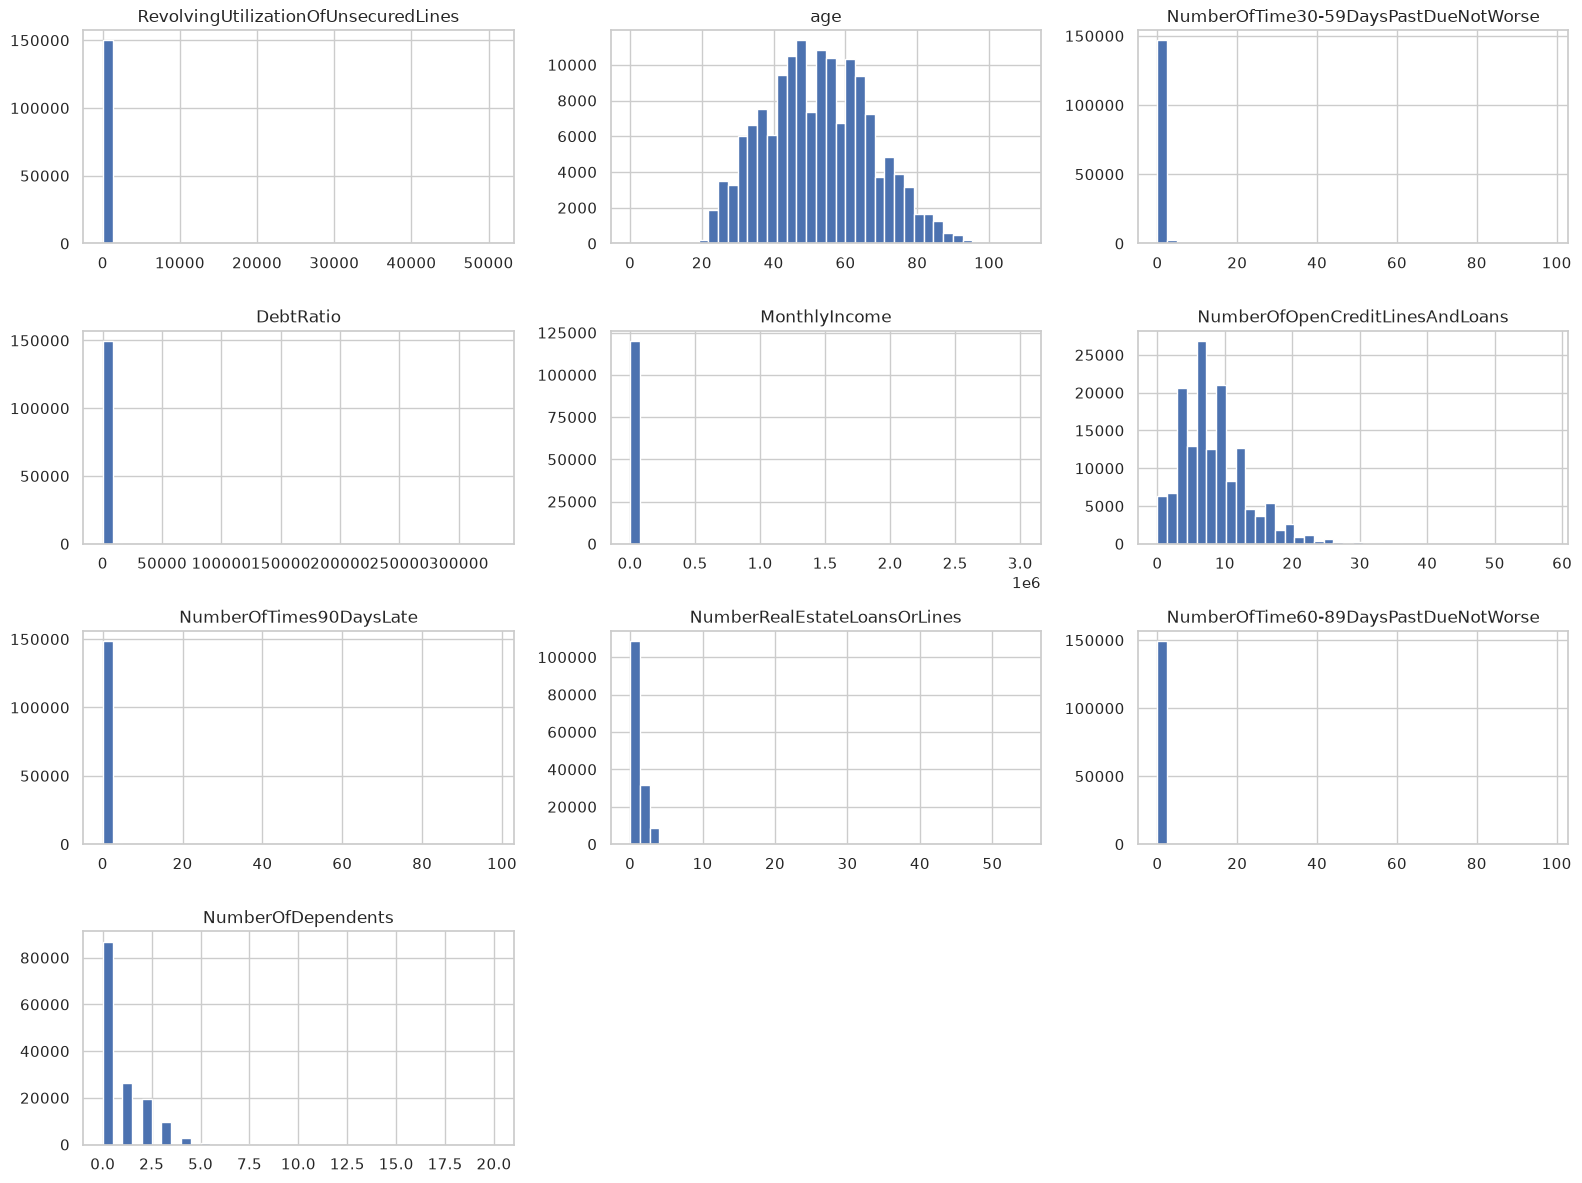

In [7]:
columnas_numericas = df.columns.drop("SeriousDlqin2yrs")
df[columnas_numericas].hist(figsize=(16, 12), bins=40)
plt.tight_layout()
plt.show()

## 5. Outliers y valores anomalos

Este dataset tiene inconsistencias conocidas:
- `age` tiene al menos un registro con edad 0.
- `RevolvingUtilizationOfUnsecuredLines` y `DebtRatio` deberian ser proporciones pero   tienen valores extremos (miles).
- `NumberOfTime30-59DaysPastDueNotWorse`, `NumberOfTime60-89DaysPastDueNotWorse` y   `NumberOfTimes90DaysLate` tienen un codigo especial (96/98) que no es un valor real.

In [8]:
print("Edades minimas:", sorted(df['age'].unique())[:5])
print("Clientes con age == 0:", (df['age'] == 0).sum())

Edades minimas: [np.int64(0), np.int64(21), np.int64(22), np.int64(23), np.int64(24)]
Clientes con age == 0: 1


In [9]:
for col in ["NumberOfTime30-59DaysPastDueNotWorse",
            "NumberOfTime60-89DaysPastDueNotWorse",
            "NumberOfTimes90DaysLate"]:
    print(col)
    print(df[col].value_counts().sort_index(ascending=False).head(5))
    print()

NumberOfTime30-59DaysPastDueNotWorse
NumberOfTime30-59DaysPastDueNotWorse
98    264
96      5
13      1
12      2
11      1
Name: count, dtype: int64

NumberOfTime60-89DaysPastDueNotWorse
NumberOfTime60-89DaysPastDueNotWorse
98    264
96      5
11      1
9       1
8       2
Name: count, dtype: int64

NumberOfTimes90DaysLate
NumberOfTimes90DaysLate
98    264
96      5
17      1
15      2
14      2
Name: count, dtype: int64



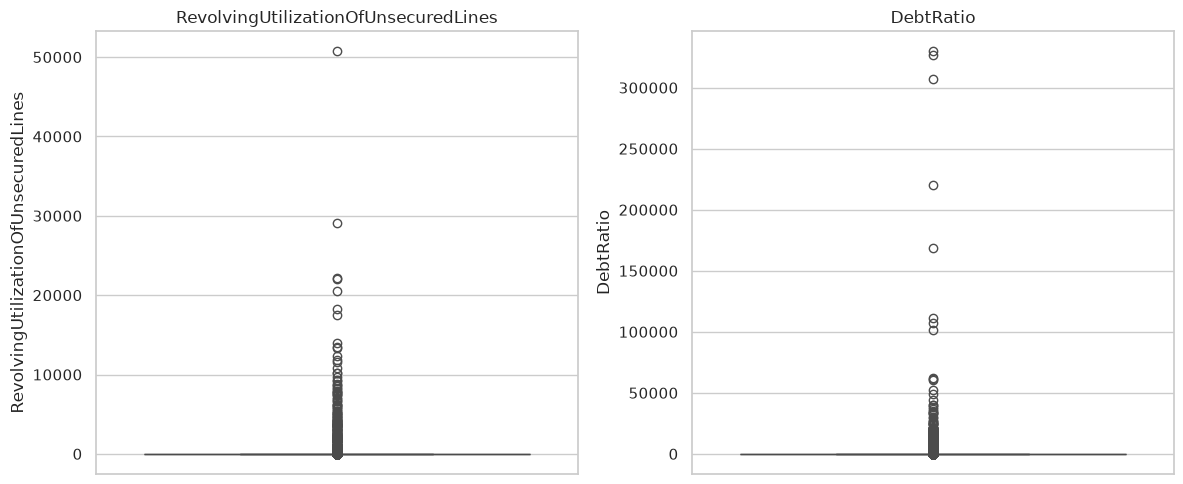

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(y=df["RevolvingUtilizationOfUnsecuredLines"], ax=axes[0])
axes[0].set_title("RevolvingUtilizationOfUnsecuredLines")
sns.boxplot(y=df["DebtRatio"], ax=axes[1])
axes[1].set_title("DebtRatio")
plt.tight_layout()
plt.show()

## 6. Correlacion entre variables

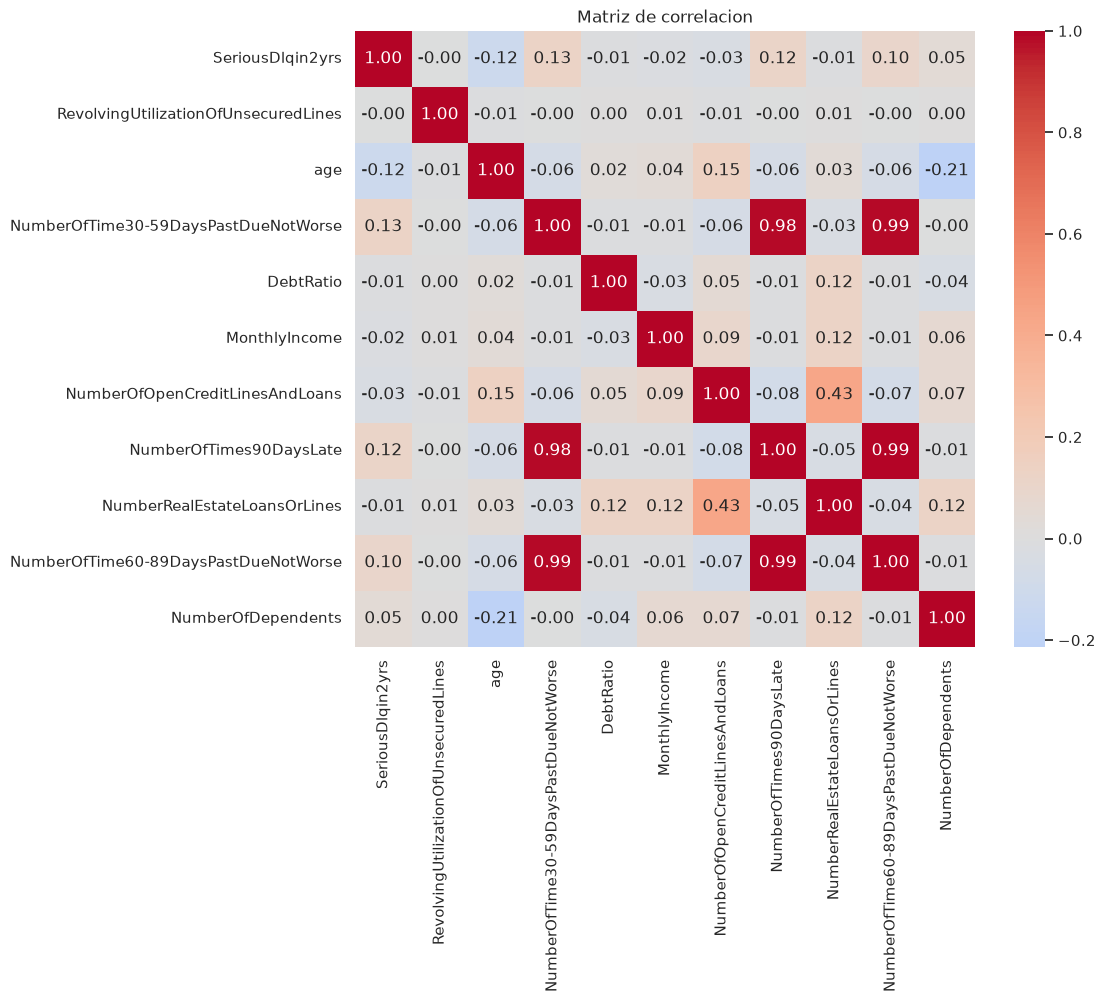

In [11]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Matriz de correlacion")
plt.show()

**Hallazgo:** las tres variables de atrasos historicos (`NumberOfTime30-59...`, `NumberOfTime60-89...`, `NumberOfTimes90DaysLate`) estan muy correlacionadas entre si y son las que mas se relacionan con la variable objetivo. Tiene sentido: el historial de pagos pasado es el mejor predictor de mora futura.

## 7. Relacion de variables clave con la variable objetivo

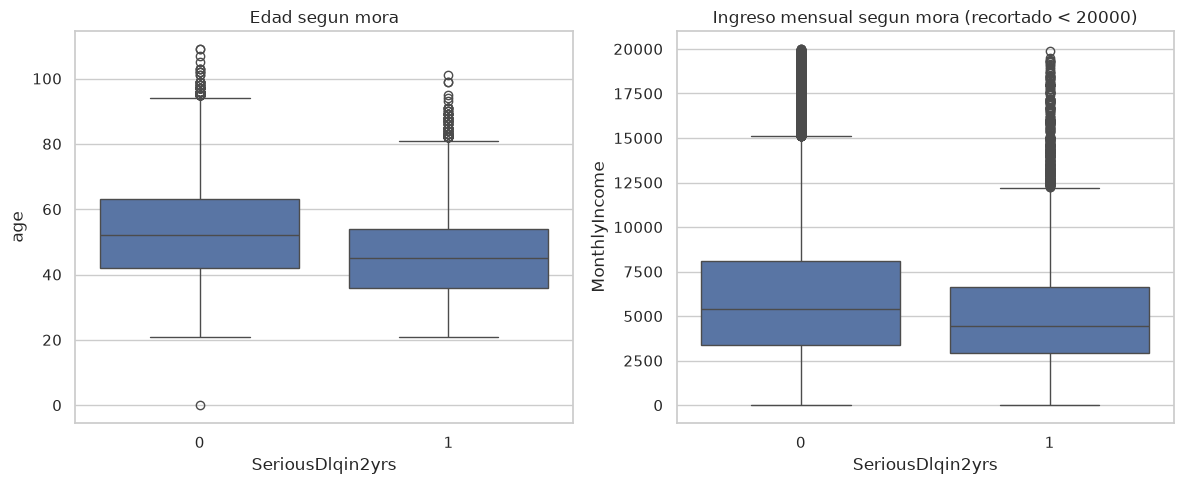

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(x="SeriousDlqin2yrs", y="age", data=df, ax=axes[0])
axes[0].set_title("Edad segun mora")
sns.boxplot(x="SeriousDlqin2yrs", y="MonthlyIncome", data=df[df["MonthlyIncome"] < 20000], ax=axes[1])
axes[1].set_title("Ingreso mensual segun mora (recortado < 20000)")
plt.tight_layout()
plt.show()

**Hallazgo:** las personas con mora tienden a ser mas jovenes y a tener ingresos mensuales declarados mas bajos, aunque la diferencia de ingreso no es enorme.

## 8. Limpieza y Feature Engineering

Se aplican las siguientes transformaciones, pensadas para no descartar informacion (los valores anomalos suelen ser justamente los casos de mayor riesgo):

- `MonthlyIncome` faltante -> se imputa con la mediana y se agrega un flag   `MonthlyIncome_faltante`.
- `NumberOfDependents` faltante -> se imputa con 0 (la moda) y se agrega un flag.
- `age == 0` -> se reemplaza por la mediana de edad (es un error de carga, no un valor real).
- Los codigos especiales 96/98 en las columnas de atraso se dejan como estan pero se   agrega un flag `atraso_codigo_especial` para que el modelo pueda usarlos como senal   aparte si corresponde.

El resultado se guarda en `dataset/cs-training-clean.csv` para reutilizarlo en los notebooks de modelado.

In [13]:
df_clean = df.copy()

df_clean["MonthlyIncome_faltante"] = df_clean["MonthlyIncome"].isnull().astype(int)
df_clean["MonthlyIncome"] = df_clean["MonthlyIncome"].fillna(df_clean["MonthlyIncome"].median())

df_clean["NumberOfDependents_faltante"] = df_clean["NumberOfDependents"].isnull().astype(int)
df_clean["NumberOfDependents"] = df_clean["NumberOfDependents"].fillna(0)

mediana_edad = df_clean.loc[df_clean["age"] > 0, "age"].median()
df_clean.loc[df_clean["age"] == 0, "age"] = mediana_edad

columnas_atraso = ["NumberOfTime30-59DaysPastDueNotWorse",
                    "NumberOfTime60-89DaysPastDueNotWorse",
                    "NumberOfTimes90DaysLate"]
df_clean["atraso_codigo_especial"] = (df_clean[columnas_atraso] >= 96).any(axis=1).astype(int)

print(df_clean.isnull().sum().sum(), "valores nulos restantes")
df_clean.to_csv("../dataset/cs-training-clean.csv", index=False)
df_clean.head()

0 valores nulos restantes


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,MonthlyIncome_faltante,NumberOfDependents_faltante,atraso_codigo_especial
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0,0,0,0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0,0,0,0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0,0,0,0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0,0,0,0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0,0,0,0


## 9. Conclusiones del AED

- El dataset tiene ~150.000 registros y 10 variables predictoras, todas numericas.
- Fuerte desbalanceo de clases (~6.7% de mora seria): condiciona la metrica de evaluacion de los modelos.
- Dos columnas con faltantes (`MonthlyIncome`, `NumberOfDependents`), imputadas con flag de "faltante" para no perder esa senal.
- Las variables de atraso historico (30-59, 60-89, 90+ dias) son las mas correlacionadas con la variable objetivo: el historial de pago es el mejor predictor.
- Hay valores anomalos conocidos del dataset (age=0, codigos 96/98) que se trataron explicitamente en vez de eliminarlos, porque suelen concentrar los casos de mayor riesgo.